In [1]:
import pandas as pd
import matplotlib.pyplot as plt
 
from rpy2.robjects import pandas2ri, r
from rpy2.robjects.packages import importr
 
pandas2ri.activate()
swmpr = importr("SWMPr")

In [27]:
# wq = salinity, DO, temp, depth
# met = meteorological data; wind speed & air temp
# mslp = mean sea level pressure

WQ  = "/Users/aaronwilson/Downloads/ZB_Data/ZB_WQ/NOCZBWQ.csv" 
MET = "/Users/aaronwilson/Downloads/ZB_Data/ZB_MET/wsp_temp.csv" # Brunswick airport ~8.2 mi
MSLP = "/Users/aaronwilson/Downloads/ZB_Data/ZB_MET/mslp.csv"    # ILM airport       ~20 mi 

In [21]:
SITE_Lat  = 33.954680     
SITE_Long = -77.934807
SITE_Tz   = "America/New_York"
METAB_Units = "mmol"

In [25]:
# Inspect raw files
with open(WQ) as f:
    print("WQ file head:")
    for _ in range(3):
        print(f.readline().rstrip())
 
with open(MET) as f:               # data availability limited to 1/22/2022-1/1/2023
    print("\nMet file head:")
    for _ in range(3):
        print(f.readline().rstrip())

with open(MSLP) as f:
    print("\nMet file head:")
    for _ in range(3):
        print(f.readline().rstrip())

WQ file head:
********LEGEND FOR FIELD NAMES LOCATED AT BOTTOM OF FILE************
Station_Code,isSWMP,m/d/y hh:mm,See Legend,See Legend,See Legend,C,Flag Code See Legend,mS/cm,Flag Code See Legend,psu,Flag Code See Legend,%,Flag Code See Legend,mg/L,Flag Code See Legend,m,Flag Code See Legend,m,Flag Code See Legend,Units,Flag Code See Legend,FNU/NTU,Flag Code See Legend
"Station_Code","isSWMP","DateTimeStamp","Historical","ProvisionalPlus","F_Record","Temp","F_Temp","SpCond","F_SpCond","Sal","F_Sal","DO_pct","F_DO_pct","DO_mgl","F_DO_mgl","Depth","F_Depth","cDepth","F_cDepth","pH","F_pH","Turb","F_Turb",

Met file head:
STATE CLIMATE OFFICE OF NORTH CAROLINA,,
Date/Time (Eastern),Top-of-the-Hour Air Temperature (F),Top-of-the-Hour Wind Speed (mph)
2022-01-22 00:00:00,29.7,9.2

Met file head:
"station,valid,mslp"
"ILM,2022-01-01 00:07,M"
"ILM,2022-01-01 00:53,1015.00"


In [29]:
import pandas as pd

In [97]:
wq = pd.read_csv(WQ, skiprows=2)

wq = wq.rename(columns={
    "DateTimeStamp": "datetimestamp",
    "Temp": "temp",
    "Sal": "sal",
    "DO_mgl": "do_mgl",
    "Depth": "depth",
})

wq = wq[["datetimestamp", "temp", "sal", "do_mgl", "depth"]]

wq["datetimestamp"] = pd.to_datetime(wq["datetimestamp"], format="%m/%d/%Y %H:%M")

wq["temp"] = pd.to_numeric(wq["temp"], errors="coerce") # Drop missing values
wq["sal"] = pd.to_numeric(wq["sal"], errors="coerce")
wq["do_mgl"] = pd.to_numeric(wq["do_mgl"], errors="coerce")
wq["depth"] = pd.to_numeric(wq["depth"], errors="coerce")

In [39]:
met = pd.read_csv(MET, skiprows=1)

met = met.rename(columns={
    "Date/Time (Eastern)": "datetimestamp",
    "Top-of-the-Hour Air Temperature (F)": "atemp_f",
    "Top-of-the-Hour Wind Speed (mph)": "wspd_mph",
})

met = met[["datetimestamp", "atemp_f", "wspd_mph"]]

met["datetimestamp"] = pd.to_datetime(met["datetimestamp"])

met["atemp_f"] = pd.to_numeric(met["atemp_f"], errors="coerce")
met["wspd_mph"] = pd.to_numeric(met["wspd_mph"], errors="coerce")

met["atemp"] = (met["atemp_f"] - 32) * 5 / 9   # F to C for ecometab formatting
met["wspd"] = met["wspd_mph"] * 0.44704        # mph to m/s

met = met[["datetimestamp", "atemp", "wspd"]]

In [49]:
from io import StringIO # fixing rows wrapped in " " so can parse columns correctly

with open(MSLP) as f:
    lines = [line.strip().strip('"') for line in f]

mslp = pd.read_csv(StringIO("\n".join(lines)))

mslp["datetimestamp"] = pd.to_datetime(mslp["valid"])

mslp["bp"] = pd.to_numeric(mslp["mslp"], errors="coerce")

mslp = mslp[["datetimestamp", "bp"]]

print(mslp.columns)
print(mslp.head())
print(len(mslp))

Index(['datetimestamp', 'bp'], dtype='object')
        datetimestamp      bp
0 2022-01-01 00:07:00     NaN
1 2022-01-01 00:53:00  1015.0
2 2022-01-01 01:30:00     NaN
3 2022-01-01 01:40:00     NaN
4 2022-01-01 01:53:00  1014.9
11238


In [57]:
# merge wind speed & air temp with sea level pressure for meteorological data
# merge meteorological data and water quaity for ecometab data
met_mslp = pd.merge(met, mslp, on="datetimestamp", how="inner")
wq_met = pd.merge(wq, met_mslp, on="datetimestamp", how="inner")

In [59]:
print("wq rows:", len(wq))
print("met rows:", len(met))
print("mslp rows:", len(mslp))
print("met_mslp rows:", len(met_joined))
print("wq_met rows:", len(wq_met))

wq_sorted = wq.sort_values("datetimestamp")
print(wq_sorted["datetimestamp"].diff().value_counts().head())

wq rows: 35175
met rows: 8280
mslp rows: 11238
met_mslp rows: 80
wq_met rows: 80
datetimestamp
0 days 00:15:00    35135
Name: count, dtype: int64


In [69]:
print(wq["datetimestamp"].isna().sum()) 

wq = wq.dropna(subset=["datetimestamp"]) # dropped 39 missing values

0


In [75]:
# sorting tables by time so merge_asof runs. ensuring timestamps between WQ and MET data align.
wq = wq.sort_values("datetimestamp")
met_mslp = met_mslp.sort_values("datetimestamp")

wq_met = pd.merge_asof(             # match each 15 min WQ reading to nearest hourly weather
    wq, met_mslp,                   # wq table reads every 15 min, met every hour. if no met data within 30 min of WQ timestamp, NaN :/
    on="datetimestamp",
    direction="nearest",
    tolerance=pd.Timedelta("30min"),
)

print(len(wq), len(wq_met))         # Ensure alignment

35136 35136


In [79]:
wq_met = wq_met.sort_values("datetimestamp").reset_index(drop=True)
print(wq_met["datetimestamp"].isna().sum())

0


In [83]:
wq_r = wq_met[cols].copy()
wq_r["datetimestamp"] = wq_r["datetimestamp"].dt.strftime("%Y-%m-%d %H:%M:%S")

r_df = pandas2ri.py2rpy(wq_r)
r.assign("rdata", r_df)

r(f'''
rdata$datetimestamp <- as.POSIXct(
  rdata$datetimestamp,
  format = "%Y-%m-%d %H:%M:%S",
  tz = "{SITE_Tz}"
)
rdata <- subset(rdata, !is.na(datetimestamp))
''')

na_timestamps = r('sum(is.na(rdata$datetimestamp))')[0]
print(na_timestamps)

0


In [85]:
from rpy2.robjects import pandas2ri, r
from rpy2.robjects.packages import importr

pandas2ri.activate()
swmpr = importr("SWMPr")

# ecometab expects exactly these columns, in this order
cols = ["datetimestamp", "do_mgl", "depth", "atemp", "sal", "temp", "wspd", "bp"]

wq_r = wq_met[cols].copy()
wq_r["datetimestamp"] = wq_r["datetimestamp"].dt.strftime("%Y-%m-%d %H:%M:%S")

r_df = pandas2ri.py2rpy(wq_r)
r.assign("rdata", r_df)

r(f'''
rdata$datetimestamp <- as.POSIXct(
  rdata$datetimestamp,
  format = "%Y-%m-%d %H:%M:%S",
  tz = "{SITE_Tz}"
)
rdata <- subset(rdata, !is.na(datetimestamp))
''')
# dropped 4 rows, timestamps that failed to convert to R (daylight savings)

na_timestamps = r('sum(is.na(rdata$datetimestamp))')[0]
print(na_timestamps)

results_r = swmpr.ecometab(
    dat_in=r["rdata"],
    tz=SITE_Tz,
    lat=SITE_Lat,
    long=SITE_Long,
    metab_units=METAB_Units,
)

results = pandas2ri.rpy2py(results_r)
print(results.head())

0
      date         DOF_d  D_d     DOF_n  D_n  Pg  Rt  NEM
1  18992.0           NaN  NaN       NaN  NaN NaN NaN  NaN
2  18993.0  5.360296e-16  NaN -0.691980  NaN NaN NaN  NaN
3  18994.0 -1.453157e+00  NaN  1.037969  NaN NaN NaN  NaN
4  18995.0  2.906314e+00  NaN  4.843857  NaN NaN NaN  NaN
5  18996.0 -9.687713e-01  NaN -3.805887  NaN NaN NaN  NaN


In [87]:
results["date"] = pd.to_datetime(results["date"], unit="D", origin="1970-01-01")
print(results.head())

        date         DOF_d  D_d     DOF_n  D_n  Pg  Rt  NEM
1 2021-12-31           NaN  NaN       NaN  NaN NaN NaN  NaN
2 2022-01-01  5.360296e-16  NaN -0.691980  NaN NaN NaN  NaN
3 2022-01-02 -1.453157e+00  NaN  1.037969  NaN NaN NaN  NaN
4 2022-01-03  2.906314e+00  NaN  4.843857  NaN NaN NaN  NaN
5 2022-01-04 -9.687713e-01  NaN -3.805887  NaN NaN NaN  NaN


In [89]:
print(wq_r[["atemp", "wspd", "bp", "do_mgl", "depth", "sal", "temp"]].isna().sum())

atemp     2562
wspd      2562
bp        4156
do_mgl    1683
depth     1707
sal       1683
temp         3
dtype: int64


In [91]:
results_clean = results[results["date"] >= "2022-01-22"]
print(len(results_clean))
print(results_clean.isna().sum())

345
date      0
DOF_d    17
D_d      18
DOF_n    17
D_n      18
Pg       18
Rt       18
NEM      18
dtype: int64


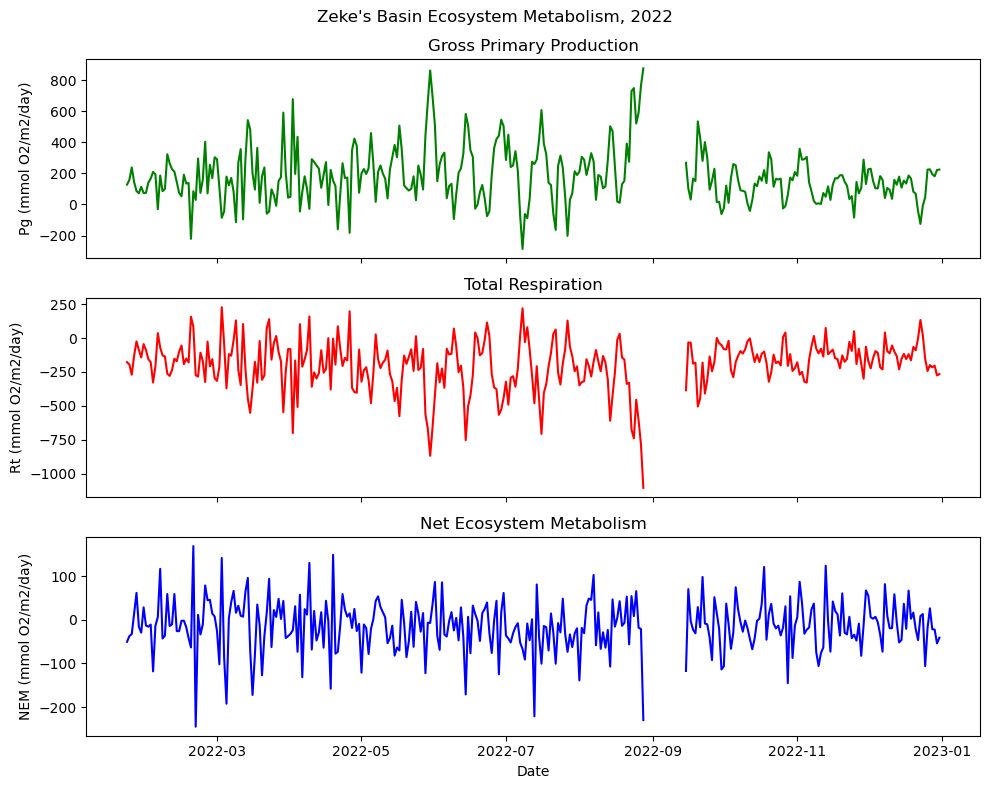

In [95]:
# Results
results_clean = results[results["date"] >= "2022-01-22"].copy() # reliable meteorological data begins @ 1/22

results_clean.to_csv("Zb_Ecometab.csv", index=False)

# plot GPP, Respiration, NEM
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axes[0].plot(results_clean["date"], results_clean["Pg"], color="green")
axes[0].set_ylabel("Pg (mmol O2/m2/day)")
axes[0].set_title("Gross Primary Production")

axes[1].plot(results_clean["date"], results_clean["Rt"], color="red")
axes[1].set_ylabel("Rt (mmol O2/m2/day)")
axes[1].set_title("Total Respiration")

axes[2].plot(results_clean["date"], results_clean["NEM"], color="blue")
axes[2].set_ylabel("NEM (mmol O2/m2/day)")
axes[2].set_title("Net Ecosystem Metabolism")
axes[2].set_xlabel("Date")

fig.suptitle("Zeke's Basin Ecosystem Metabolism, 2022")
plt.tight_layout()
plt.savefig("zekes_basin_metabolism_2022.png", dpi=300)
plt.show()